In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from timeit import repeat

In [2]:
from linear_regression import LinearRegression as cust_LinearRegression 
from ridge_regression import RidgeRegression as cust_RidgeRegression
from polynomial_regression import PolynomialRegression as cust_PolynomialRegression

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [3]:
rng = np.random.default_rng(seed=42)

# Linear Regression — scratch vs sklearn

This section validates the custom `LinearRegression` implementation against `sklearn.linear_model.LinearRegression`. We compare on three axes:

1. **Coefficient agreement** — do the closed-form (normal-equation) solutions match?
2. **Solver consistency** — does the custom gradient-descent solver converge to the same coefficients?
3. **Performance** — how does fit time scale with the number of features?

> Note: the custom implementation prepends a bias column to `X`, so `coef_[0]` is the intercept and `coef_[1:]` is comparable to sklearn's `coef_`.

In [4]:
# §1 — Sanity check: closed-form solutions on a small problem

X, y = make_regression(
    n_samples=200, n_features=10, n_informative=8,
    noise=12.0, random_state=42,
)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr = sc.fit_transform(X_tr)
X_te = sc.transform(X_te)

custom = cust_LinearRegression(solver="normal").fit(X_tr, y_tr)
sk     = LinearRegression().fit(X_tr, y_tr)

# coef_[0] is the intercept in the custom impl; coef_[1:] aligns with sklearn.coef_
custom_intercept = float(custom.coef_[0])
custom_coefs     = custom.coef_[1:]

print(f"intercept        custom = {custom_intercept:>12.6f}    sklearn = {sk.intercept_:>12.6f}")
print(f"|Δ intercept|           = {abs(custom_intercept - sk.intercept_):.3e}")
print(f"max |Δ coef|            = {np.max(np.abs(custom_coefs - sk.coef_)):.3e}")
print(f"max |Δ ŷ|  (test)       = {np.max(np.abs(custom.predict(X_te) - sk.predict(X_te))):.3e}")
print()
print(f"R² (custom)  = {r2_score(y_te, custom.predict(X_te)):.6f}")
print(f"R² (sklearn) = {r2_score(y_te, sk.predict(X_te)):.6f}")

intercept        custom =    14.764945    sklearn =    14.764945
|Δ intercept|           = 5.329e-15
max |Δ coef|            = 3.446e-13
max |Δ ŷ|  (test)       = 1.194e-12

R² (custom)  = 0.993660
R² (sklearn) = 0.993660


## §2 — Numerical agreement across multiple datasets

Replicate the comparison over a grid of `(n_samples, n_features, noise)` configurations so the equivalence isn't specific to one dataset. The expected outcome: `max |Δcoef|` and `max |Δŷ|` should be at floating-point noise level (≈ 1e-10 or smaller) in every row.

In [6]:
configs = [
    # (n_samples, n_features, noise)
    (100,     5,   1.0),
    (500,    20,  10.0),
    (1000,   50,  15.0),
    (2000,  100,  20.0),
    (500,   200,  10.0),   # p approaching n
    (5000, 1000,  15.0),   # large dimensionality
]

records = []
for n, p, noise in configs:
    X, y = make_regression(
        n_samples=n, n_features=p,
        n_informative=max(1, p - p // 2),
        noise=noise, random_state=42,
    )
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)

    custom = cust_LinearRegression(solver="normal").fit(X_tr, y_tr)
    sk     = LinearRegression().fit(X_tr, y_tr)

    records.append({
        "n":             n,
        "p":             p,
        "noise":         noise,
        "max |Δ coef|":  float(np.max(np.abs(custom.coef_[1:] - sk.coef_))),
        "max |Δ ŷ|":     float(np.max(np.abs(custom.predict(X_te) - sk.predict(X_te)))),
        "R² custom":     r2_score(y_te, custom.predict(X_te)),
        "R² sklearn":    r2_score(y_te, sk.predict(X_te)),
    })

agreement = pd.DataFrame(records)
agreement

,n,p,noise,max |Δ coef|,max |Δ ŷ|,R² custom,R² sklearn
0,100,5,1.0,1.207923e-13,2.557954e-13,0.999847,0.999847
1,500,20,10.0,2.958744e-13,1.573852e-12,0.994813,0.994813
2,1000,50,15.0,3.154699e-13,2.728484e-12,0.996864,0.996864
3,2000,100,20.0,3.410605e-13,4.774847e-12,0.998182,0.998182
4,500,200,10.0,5.826450e-13,5.684342e-12,0.999293,0.999293
5,5000,1000,15.0,1.019629e-12,3.132072e-11,0.999844,0.999844


## §3 — Gradient-descent solver vs closed form

The custom `gradient_descent` solver is iterative, so its coefficients should *approximate* those of the normal-equation / sklearn solutions. Two checks:

- **Coefficients overlay**: bar chart of `(custom-normal, custom-GD, sklearn)` per coefficient.
- **Loss curve**: the GD `loss_history` should decrease monotonically and plateau.

Disagreement should shrink with more iterations or a better learning rate. Large gaps are a sign of poor convergence (lr too small / ill-conditioned `X`).

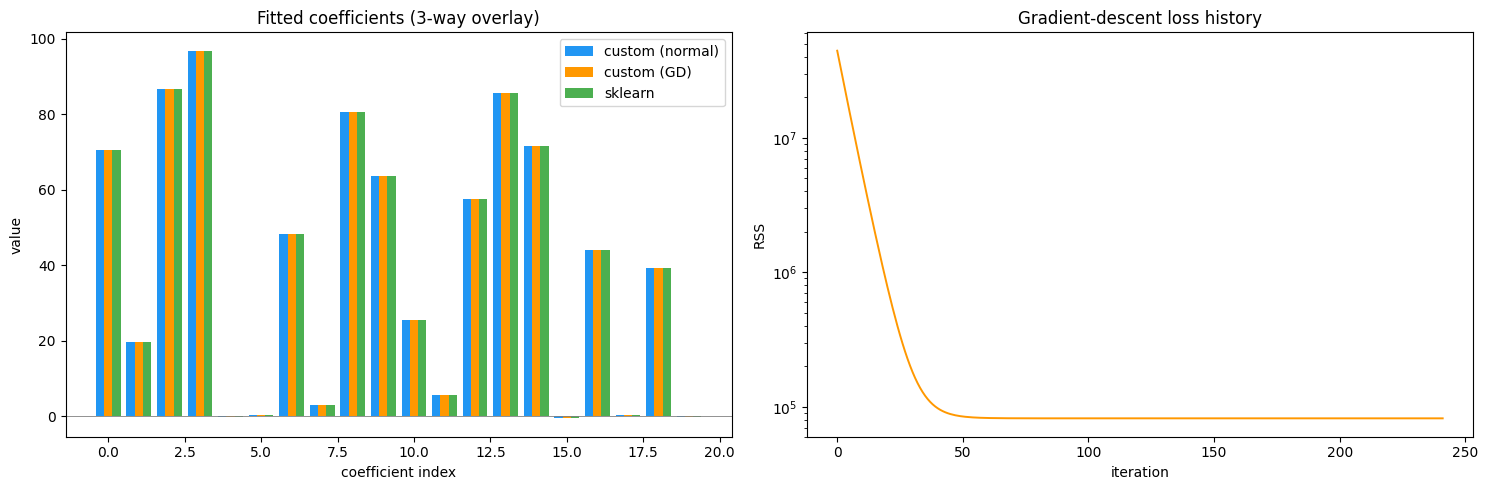

max |Δ coef|  (normal vs GD)      = 2.624e-07
max |Δ coef|  (normal vs sklearn) = 3.837e-13

R² (normal):  0.998035
R² (GD):      0.998035
R² (sklearn): 0.998035


In [7]:
X, y = make_regression(
    n_samples=1000, n_features=20, n_informative=15,
    noise=10.0, random_state=42,
)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)

normal_fit = cust_LinearRegression(solver="normal").fit(X_tr, y_tr)
gd_fit     = cust_LinearRegression(solver="gradient_descent",
                                   lr=0.05, n_iter=5000, tol=1e-9).fit(X_tr, y_tr)
sk_fit     = LinearRegression().fit(X_tr, y_tr)

# ---- coefficient overlay + loss curve ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

idx = np.arange(len(normal_fit.coef_) - 1)
width = 0.27
ax = axes[0]
ax.bar(idx - width, normal_fit.coef_[1:], width, label="custom (normal)", color="#2196F3")
ax.bar(idx,         gd_fit.coef_[1:],     width, label="custom (GD)",     color="#FF9800")
ax.bar(idx + width, sk_fit.coef_,         width, label="sklearn",         color="#4CAF50")
ax.axhline(0, color="gray", linewidth=0.6)
ax.set(xlabel="coefficient index", ylabel="value",
       title="Fitted coefficients (3-way overlay)")
ax.legend()

ax = axes[1]
if len(gd_fit.loss_history):
    ax.plot(gd_fit.loss_history, color="#FF9800", linewidth=1.4)
    ax.set(xlabel="iteration", ylabel="RSS", yscale="log",
           title="Gradient-descent loss history")

plt.tight_layout(); plt.show()

print(f"max |Δ coef|  (normal vs GD)      = {np.max(np.abs(normal_fit.coef_[1:] - gd_fit.coef_[1:])):.3e}")
print(f"max |Δ coef|  (normal vs sklearn) = {np.max(np.abs(normal_fit.coef_[1:] - sk_fit.coef_)):.3e}")
print()
print(f"R² (normal):  {r2_score(y_te, normal_fit.predict(X_te)):.6f}")
print(f"R² (GD):      {r2_score(y_te, gd_fit.predict(X_te)):.6f}")
print(f"R² (sklearn): {r2_score(y_te, sk_fit.predict(X_te)):.6f}")

## §4 — Fit-time benchmark

How does the custom closed-form solver scale against sklearn as `n_features` grows? Sklearn uses LAPACK's `gelsd` (SVD-based least squares) under the hood; the custom impl uses `scipy.linalg.lstsq`, which calls into the same LAPACK family — so the gap should be small and roughly constant.

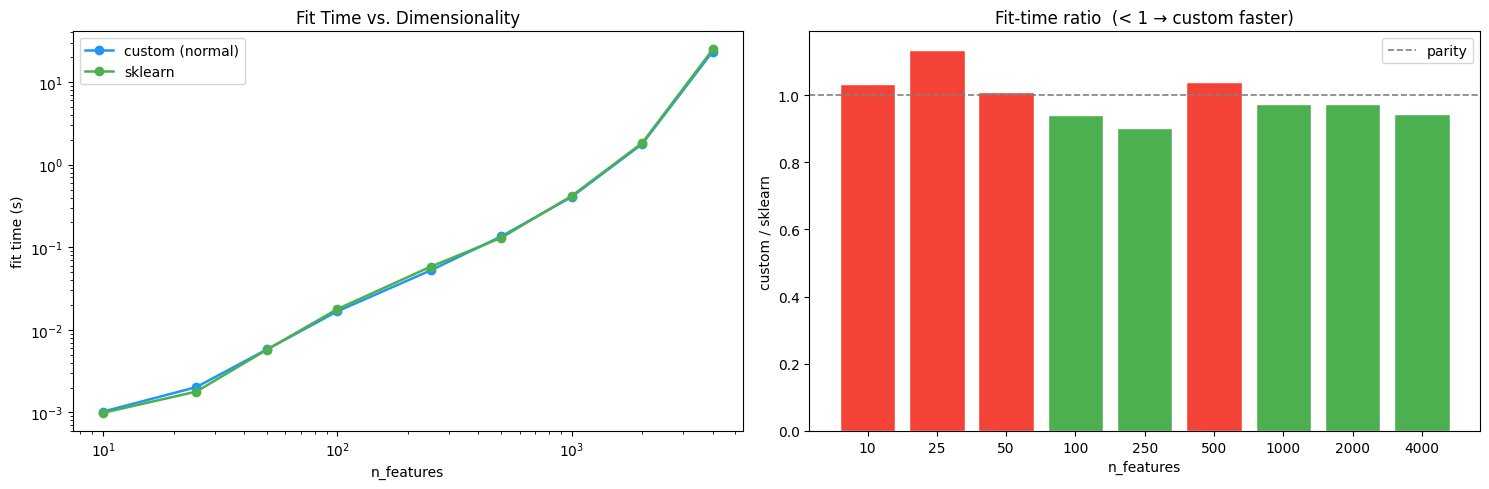

,n_features,fit_time_custom,fit_time_sklearn,ratio (cust/sk),R² custom,R² sklearn
0,10,0.001022,0.000989,1.033745,0.988374,0.988374
1,25,0.002024,0.001786,1.132959,0.995858,0.995858
2,50,0.005784,0.005740,1.007543,0.997281,0.997281
3,100,0.016747,0.017829,0.939321,0.998651,0.998651
4,250,0.052389,0.058065,0.902254,0.999443,0.999443
5,500,0.134890,0.129889,1.038507,0.999720,0.999720
6,1000,0.406681,0.417279,0.974602,0.999844,0.999844
7,2000,1.779366,1.828053,0.973367,0.999846,0.999846
8,4000,23.408190,24.790122,0.944255,0.953429,0.953429


In [8]:
feature_grid = [10, 25, 50, 100, 250, 500, 1000, 2000, 4000]
N_REPEATS = 5

records = []
for p in feature_grid:
    X, y = make_regression(
        n_samples=5000, n_features=p,
        n_informative=max(1, p - p // 2),
        noise=15.0, random_state=42,
    )
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)

    cust = cust_LinearRegression(solver="normal")
    sk   = LinearRegression()

    t_cust = np.mean(repeat(lambda: cust.fit(X_tr, y_tr), number=1, repeat=N_REPEATS))
    t_sk   = np.mean(repeat(lambda: sk.fit(X_tr, y_tr),   number=1, repeat=N_REPEATS))

    records.append({
        "n_features":      p,
        "fit_time_custom": t_cust,
        "fit_time_sklearn": t_sk,
        "ratio (cust/sk)": t_cust / t_sk,
        "R² custom":  r2_score(y_te, cust.predict(X_te)),
        "R² sklearn": r2_score(y_te, sk.predict(X_te)),
    })

bench = pd.DataFrame(records)

# ---- plot ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(bench["n_features"], bench["fit_time_custom"],  marker="o",
        label="custom (normal)", color="#2196F3", linewidth=1.8)
ax.plot(bench["n_features"], bench["fit_time_sklearn"], marker="o",
        label="sklearn",         color="#4CAF50", linewidth=1.8)
ax.set(xlabel="n_features", ylabel="fit time (s)",
       xscale="log", yscale="log",
       title="Fit Time vs. Dimensionality")
ax.legend()

ax = axes[1]
ax.bar(np.arange(len(bench)), bench["ratio (cust/sk)"],
       color=["#4CAF50" if r < 1 else "#F44336" for r in bench["ratio (cust/sk)"]],
       edgecolor="white")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1.2, label="parity")
ax.set_xticks(np.arange(len(bench)))
ax.set_xticklabels(bench["n_features"])
ax.set(xlabel="n_features", ylabel="custom / sklearn",
       title="Fit-time ratio  (< 1 → custom faster)")
ax.legend()

plt.tight_layout(); plt.show()
bench